# 10 — Income as a Third Spatial Layer: CV Comparison and Income-Weighted Person-Days

Notebooks 04–07 showed that person-day rankings within Salvador are almost entirely driven
by population variation (CV ≈ 1.04) rather than heat-day variation (CV ≈ 0.44).  This
notebook introduces a third spatial dimension — **household income from the 2022 Brazilian
Census** — to ask two questions:

1. How does income inequality (CV of mean income across neighbourhoods) compare to the
   spatial inequality in heat exposure and population?
2. Can we weight person-days by income vulnerability to better surface neighbourhoods that
   are *both* heat-exposed *and* economically marginalised?

**Income data:** `renda_responsavel_2927408_georedus_censo_2022.geojson`  
Field `renda_responsavel` = mean monthly income of household head per census sector (BRL).  
4 542 census sectors; 66 null records dropped before aggregation.

**Aggregation challenge:** income is reported at census sector level (~4 500 units);
heat and population data are aggregated to the 22 Salvador neighbourhood boundaries
from the 2010 GeoPackage.  Census sectors must be re-aggregated to the 22-neighbourhood
level before comparison.  See the critique section for known limitations.

**Prerequisites:** `01_data_acquisition`, `02_compute_baselines`, `07_person_days_diagnostic`.

## Setup

In [16]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
from scipy.stats import spearmanr

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    load_city, load_tx90p_threshold, load_neighbourhood_boundaries,
    compute_absolute_heat_days, compute_person_days_map,
    aggregate_to_neighbourhoods, aggregate_person_days_to_neighbourhoods,
)

DATA_DIR      = 'data'
DIAG_YEAR     = 2020
ABS_THRESHOLD = 30.0
PERCENTILE    = 90
CITY_KEY      = 'salvador'
INCOME_FILE   = 'data/renda_responsavel_2927408_georedus_censo_2022.geojson'
PROJ_CRS      = 'EPSG:31984'   # SIRGAS 2000 / UTM zone 24S — metric CRS for Salvador

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th',      'props': 'text-align:center; white-space:nowrap; font-size:0.85em;'},
    {'selector': 'td',      'props': 'text-align:center; font-size:0.85em;'},
]

def load_pop_grid(city, year):
    import xarray as xr
    return xr.open_dataset(f'{DATA_DIR}/{city}_pop_1km_{year}.nc')['population']

def count_doy_exceedances(da, thresh_doy):
    aligned = thresh_doy.sel(dayofyear=da.time.dt.dayofyear)
    return (da > aligned).resample(time='YS').sum(dim='time')

## Step 1 — Load Salvador neighbourhood boundaries

The 22-polygon GeoPackage used in notebooks 04–07 is the target aggregation level for all
three variables (heat, population, income).

In [17]:
districts = load_neighbourhood_boundaries(CITY_KEY, DATA_DIR)
print(f"Loaded {len(districts)} Salvador neighbourhoods")
print(f"CRS: {districts.crs}")
print(districts[['name']].to_string())

Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg
Loaded 22 Salvador neighbourhoods
CRS: EPSG:4326
                  name
0            Amaralina
1               Brotas
2   Conceição Da Praia
3               Itapoã
4               Pirajá
5        Santo Antônio
6          São Caetano
7        São Cristovão
8                 Maré
9                Mares
10              Nazaré
11              Paripe
12               Passo
13               Penha
14            Periperi
15               Pilar
16          Plataforma
17             Santana
18           São Pedro
19                  Sé
20             Valéria
21             Vitória


## Step 2 — Load income data (census sector level)

The income GeoJSON contains polygon geometries for 4 542 census sectors.  Null records
(66 sectors, likely uninhabited or commercial zones) are dropped before aggregation.
The income distribution is right-skewed: median ≈ 1 638 BRL vs mean ≈ 3 127 BRL, with
a maximum of 61 671 BRL in the wealthiest sector.

In [18]:
income_raw = gpd.read_file(INCOME_FILE)
print(f"Raw census sectors: {len(income_raw)}")
print(f"Null renda_responsavel: {income_raw['renda_responsavel'].isna().sum()}")

income_gdf = income_raw.dropna(subset=['renda_responsavel']).reset_index(drop=True)
print(f"After dropping nulls: {len(income_gdf)}")

# Reproject to match district CRS
income_gdf = income_gdf.to_crs(districts.crs)

print("\nIncome distribution (BRL/month):")
display(income_gdf['renda_responsavel'].describe().to_frame().T.style
    .format('{:.1f}')
    .set_caption('renda_responsavel — household head monthly income, BRL')
    .set_table_styles(table_styles))

Raw census sectors: 4542
Null renda_responsavel: 66
After dropping nulls: 4476

Income distribution (BRL/month):


,count,mean,std,min,25%,50%,75%,max
renda_responsavel,4476.0,3126.6,3643.7,770.1,1332.8,1637.9,3084.6,61671.4


## Step 3 — Aggregate census sectors to neighbourhoods (centroid method)

Both layers are first reprojected to **EPSG:31984** (SIRGAS 2000 / UTM zone 24S), the
standard metric CRS for Salvador, before centroid computation.  Computing centroids in
geographic degrees (EPSG:4326) produces inaccurate results because a degree of longitude
is shorter near the equator than at the poles — a planar CRS ensures the centroid is the
true geometric centre of each polygon in metres.

Each census sector is then reduced to its centroid point and assigned to the neighbourhood
polygon containing it (`predicate='within'`).  Income per neighbourhood is the **simple
mean** of all sector incomes whose centroids fall inside that polygon.

Any centroid that falls outside all 22 polygons (e.g. coastal sectors straddling the
boundary) is assigned to the nearest neighbourhood by Euclidean distance in the projected
CRS.

In [19]:
# --- Project both layers to metric CRS before centroid computation -----------
# Centroids computed in geographic degrees (EPSG:4326) are inaccurate;
# EPSG:31984 (SIRGAS 2000 / UTM 24S) is the standard metric CRS for Salvador.
income_proj   = income_gdf.to_crs(PROJ_CRS)
districts_proj = districts.to_crs(PROJ_CRS)

# --- Centroid spatial join ---------------------------------------------------
income_pts = income_proj[['id', 'renda_responsavel']].copy()
income_pts['geometry'] = income_proj.geometry.centroid
income_pts = gpd.GeoDataFrame(income_pts, crs=PROJ_CRS)

joined = gpd.sjoin(
    income_pts,
    districts_proj[['name', 'geometry']],
    how='left',
    predicate='within',
)

# --- Fallback: nearest neighbourhood for unmatched centroids -----------------
unmatched_mask = joined['name'].isna()
n_unmatched = unmatched_mask.sum()
print(f"Centroids matched within polygon : {(~unmatched_mask).sum()}")
print(f"Unmatched (fallback to nearest)  : {n_unmatched}")

if n_unmatched > 0:
    unmatched_pts = income_pts.loc[unmatched_mask].copy()
    nearest = gpd.sjoin_nearest(
        unmatched_pts,
        districts_proj[['name', 'geometry']],
        how='left',
    )[['name']]
    joined.loc[unmatched_mask, 'name'] = nearest['name'].values

# --- Simple mean income per neighbourhood ------------------------------------
income_by_nbhd = (
    joined
    .groupby('name')['renda_responsavel']
    .agg(mean_income='mean', n_sectors='count', std_income='std')
    .reset_index()
)

print(f"\nNeighbourhoods with income data: {len(income_by_nbhd)} / {len(districts)}")
print(f"Sectors per neighbourhood: min={income_by_nbhd['n_sectors'].min()}, "
      f"max={income_by_nbhd['n_sectors'].max()}, "
      f"mean={income_by_nbhd['n_sectors'].mean():.0f}")

display(income_by_nbhd.sort_values('mean_income', ascending=False).style
    .format({'mean_income': '{:.0f}', 'std_income': '{:.0f}', 'n_sectors': '{:.0f}'})
    .bar(subset=['mean_income'], color='#2ca25f', vmin=0)
    .set_caption('Mean income per neighbourhood (BRL/month) — simple mean of census sector values')
    .set_table_styles(table_styles))

Centroids matched within polygon : 4489
Unmatched (fallback to nearest)  : 0

Neighbourhoods with income data: 22 / 22
Sectors per neighbourhood: min=2, max=710, mean=204


,name,mean_income,n_sectors,std_income
2,Conceição Da Praia,10261,2,11867
0,Amaralina,6270,465,4553
21,Vitória,6220,342,5332
3,Itapoã,5277,307,5847
1,Brotas,4701,363,4878
6,Nazaré,3614,19,1150
18,São Pedro,3475,32,1213
14,Santana,3201,21,1075
4,Mares,2361,13,865
19,Sé,2147,5,761


## Critique of the centroid aggregation method

### Known limitations and error sources

**1. Boundary straddling (Modifiable Areal Unit Problem).** Census sectors that straddle
a neighbourhood boundary have their centroid assigned wholly to one side.  If the sector
is large, the majority of its area — and therefore its residents — may lie in the other
neighbourhood.  With ~206 sectors per neighbourhood on average this affects every boundary
in the city.  The true error is proportional to the share of boundary sectors relative to
interior sectors; it is largest in small neighbourhoods with fewer sectors.

**2. Simple mean ignores sector size.** Each sector's income value receives equal weight
regardless of how many residents it contains.  A large sector with low income should
carry more weight than a tiny sector with high income.  A **population-weighted mean**
would be correct but requires a household or resident count per sector, which is not
available in this GeoJSON.  The simple mean will therefore over-represent small
(typically high-income, low-density) sectors.

**3. Temporal mismatch.** Neighbourhood boundaries are from the **2010** IBGE GeoPackage;
income data is from the **2022** census.  Administrative boundary revisions between
censuses could cause sectors to straddle boundaries that no longer exist.  This is
difficult to correct without the 2022 neighbourhood shapefile.

**4. Within-neighbourhood inequality is erased.** Aggregating ~200 sectors to a single
mean discards potentially large within-neighbourhood income variation.  The CV we compute
below is a *between*-neighbourhood measure; high within-neighbourhood inequality (which
is common in Brazilian cities) is invisible at this scale.

**5. Right-skewed income distribution amplifies outlier sensitivity.** The income
distribution has a long upper tail (max ≈ 61 671 BRL vs median ≈ 1 638 BRL).  A single
high-income sector can noticeably shift a small neighbourhood's mean.  The min-max
normalisation in Step 8 is particularly sensitive to this outlier.

### What would be better

- **Areal interpolation** with dasymetric mapping: intersect the two polygon layers
  directly, weight by the area of each intersection fragment.  This avoids the centroid
  approximation entirely but requires an additional spatial operation.
- **Population-weighted mean** if a household count per sector becomes available from
  the full 2022 census tables.
- Use of **2022 neighbourhood boundaries** to eliminate the temporal mismatch.

The centroid approach used here is a reasonable first-order approximation at this scale
(4 500 small sectors → 22 large neighbourhoods) but results should be treated as
indicative rather than precise.

## Step 4 — Rebuild district-level heat and population metrics

Replicates the `build_nbhd_table` logic from notebook 07 for Salvador only.

In [20]:
import xarray as xr

da         = load_city(CITY_KEY, DATA_DIR)
da.attrs['units'] = 'degC'
thresh     = load_tx90p_threshold(CITY_KEY, DATA_DIR)
pop_grid   = load_pop_grid(CITY_KEY, DIAG_YEAR)

abs_hd = compute_absolute_heat_days(da, DIAG_YEAR, ABS_THRESHOLD)

tx_annual = count_doy_exceedances(da, thresh.sel(percentile=PERCENTILE))
tx_hd = (
    tx_annual
    .isel(time=(tx_annual.time.dt.year == DIAG_YEAR))
    .squeeze('time')
)

pop_nbhd    = aggregate_person_days_to_neighbourhoods(pop_grid, districts, col='population')
abs_hd_nbhd = aggregate_to_neighbourhoods(abs_hd, districts, col='abs_hd')
tx_hd_nbhd  = aggregate_to_neighbourhoods(tx_hd,  districts, col='tx90p_hd')
abs_pd_nbhd = aggregate_person_days_to_neighbourhoods(
                  compute_person_days_map(abs_hd, pop_grid), districts, col='abs_pd')
tx_pd_nbhd  = aggregate_person_days_to_neighbourhoods(
                  compute_person_days_map(tx_hd,  pop_grid), districts, col='tx90p_pd')

heat_df = districts[['name']].copy()
heat_df['population'] = pop_nbhd['population'].values
heat_df['abs_hd']     = abs_hd_nbhd['abs_hd'].values
heat_df['tx90p_hd']   = tx_hd_nbhd['tx90p_hd'].values
heat_df['abs_pd']     = abs_pd_nbhd['abs_pd'].values
heat_df['tx90p_pd']   = tx_pd_nbhd['tx90p_pd'].values
heat_df = heat_df.dropna().reset_index(drop=True)

print(f"Heat/population table: {len(heat_df)} neighbourhoods")
heat_df.head()

salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
salvador TX90p threshold: shape {'percentile': 2, 'lat': 55, 'lon': 67, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 26.0–73.7 °C
Heat/population table: 22 neighbourhoods


,name,population,abs_hd,tx90p_hd,abs_pd,tx90p_pd
0,Amaralina,270321.630615,228.750000,10.700000,6.155877e+07,2.845064e+06
1,Brotas,177033.559570,243.636364,11.727273,4.307396e+07,2.078214e+06
2,Conceição Da Praia,4688.060547,235.000000,3.000000,1.101694e+06,1.406418e+04
3,Itapoã,161716.284208,226.489796,11.265306,3.813142e+07,1.982070e+06
4,Pirajá,371435.356524,231.000000,10.948718,8.608024e+07,4.006178e+06


## Step 5 — Merge all three layers into a single district table

In [21]:
df = heat_df.merge(income_by_nbhd[['name', 'mean_income', 'n_sectors', 'std_income']],
                   on='name', how='left')

n_missing_income = df['mean_income'].isna().sum()
if n_missing_income > 0:
    print(f"WARNING: {n_missing_income} neighbourhood(s) have no income data — "
          f"check sector coverage.")
    print(df.loc[df['mean_income'].isna(), 'name'].tolist())

df = df.dropna(subset=['mean_income']).reset_index(drop=True)

# Rank all variables (1 = highest value)
for col in ['population', 'abs_hd', 'tx90p_hd', 'abs_pd', 'tx90p_pd', 'mean_income']:
    df[f'rank_{col}'] = df[col].rank(ascending=False, method='min').astype(int)

print(f"Final merged table: {len(df)} neighbourhoods")
display(df[['name', 'population', 'tx90p_hd', 'tx90p_pd', 'mean_income', 'n_sectors']]
    .sort_values('mean_income', ascending=False)
    .style
    .format({
        'population':   '{:,.0f}',
        'tx90p_hd':     '{:.1f}',
        'tx90p_pd':     '{:,.0f}',
        'mean_income':  '{:.0f}',
        'n_sectors':    '{:.0f}',
    })
    .background_gradient(subset=['mean_income'], cmap='RdYlGn')
    .set_caption(f'Salvador neighbourhoods — heat, population, income  ({DIAG_YEAR} heat/pop; 2022 income)')
    .set_table_styles(table_styles))

Final merged table: 22 neighbourhoods


,name,population,tx90p_hd,tx90p_pd,mean_income,n_sectors
2,Conceição Da Praia,"4,688",3.0,"14,064",10261,2
0,Amaralina,"270,322",10.7,"2,845,064",6270,465
21,Vitória,"139,139",8.5,"1,167,467",6220,342
3,Itapoã,"161,716",11.3,"1,982,070",5277,307
1,Brotas,"177,034",11.7,"2,078,214",4701,363
10,Nazaré,"10,163",3.0,"30,490",3614,19
18,São Pedro,"16,507",3.0,"49,521",3475,32
17,Santana,"19,484",3.0,"58,452",3201,21
9,Mares,"15,114",12.0,"181,367",2361,13
19,Sé,"10,163",3.0,"30,490",2147,5


## Step 6 — CV comparison: income vs heat days vs population

CV = std / mean across the 22 neighbourhoods.  A higher CV means greater spatial
inequality in that variable — more spread in how neighbourhoods differ from each other.

Coefficient of variation (std/mean) across 22 Salvador neighbourhoods:


,Variable,CV
0,Population,1.041
1,Abs heat days,0.441
2,TX90p heat days,0.642
3,Mean income (BRL),0.724


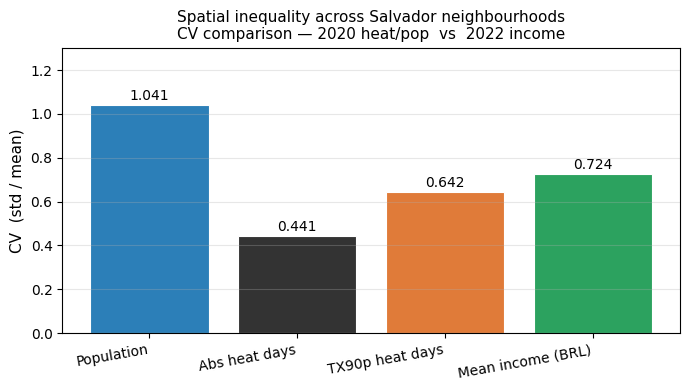

In [22]:
def cv(s):
    return s.std() / s.mean() if s.mean() != 0 else np.nan

cv_data = {
    'Population':        cv(df['population']),
    'Abs heat days':     cv(df['abs_hd']),
    'TX90p heat days':   cv(df['tx90p_hd']),
    'Mean income (BRL)': cv(df['mean_income']),
}

cv_df = pd.DataFrame({'Variable': list(cv_data.keys()), 'CV': list(cv_data.values())})
print("Coefficient of variation (std/mean) across 22 Salvador neighbourhoods:")
display(cv_df.style
    .format({'CV': '{:.3f}'})
    .bar(subset=['CV'], color='#2c7fb8', vmin=0)
    .set_caption(f'CV comparison — Salvador {DIAG_YEAR} (heat/pop) vs 2022 (income)')
    .set_table_styles(table_styles))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2c7fb8', '#333333', '#e07b39', '#2ca25f']
bars = ax.bar(cv_data.keys(), cv_data.values(), color=colors, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, cv_data.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.3f}',
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('CV  (std / mean)', fontsize=11)
ax.set_title(f'Spatial inequality across Salvador neighbourhoods\n'
             f'CV comparison — {DIAG_YEAR} heat/pop  vs  2022 income', fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(cv_data.values()) * 1.25)
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()

## Step 7 — Bivariate scatter and Spearman rank correlations

Do richer neighbourhoods also experience less heat?  Is income correlated with population
size (large neighbourhoods tend to be poorer)?  These scatters make the spatial
relationships visible before we build the composite index.

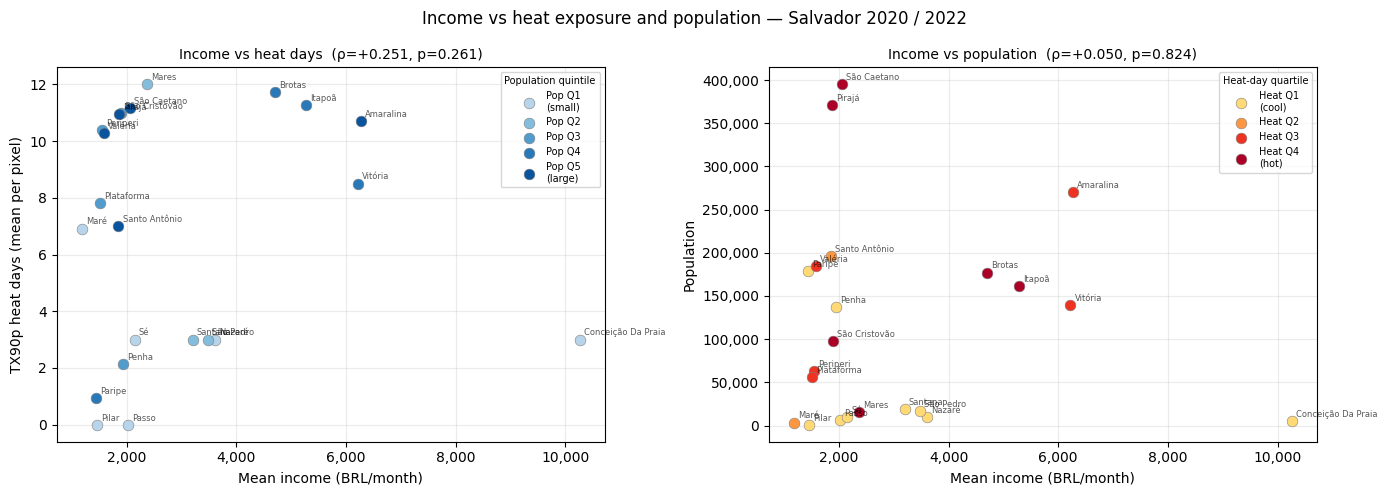

,Comparison,ρ,p-value
0,Income vs TX90p heat days,+0.251,0.2608
1,Income vs Abs heat days,+0.590,0.0038
2,Income vs Population,+0.050,0.8242
3,Income vs TX90p person-days,+0.097,0.6689
4,TX90p heat days vs Population,+0.531,0.0111
5,Population vs TX90p person-days,+0.966,0.0000


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Income vs heat exposure and population — Salvador {DIAG_YEAR} / 2022',
             fontsize=12)

# ---- Panel 1: income vs TX90p heat days (colour = population quintile) ------
ax = axes[0]
pop_q = pd.qcut(df['population'], 5, labels=['Q1\n(small)', 'Q2', 'Q3', 'Q4', 'Q5\n(large)'])
cmap  = plt.cm.Blues
for i, q in enumerate(['Q1\n(small)', 'Q2', 'Q3', 'Q4', 'Q5\n(large)']):
    mask = pop_q == q
    ax.scatter(df.loc[mask, 'mean_income'], df.loc[mask, 'tx90p_hd'],
               s=60, color=cmap(0.3 + i * 0.14), edgecolors='grey',
               linewidth=0.4, label=f'Pop {q}', zorder=3)
for _, row in df.iterrows():
    ax.annotate(row['name'], (row['mean_income'], row['tx90p_hd']),
                fontsize=6, alpha=0.65, xytext=(3, 3), textcoords='offset points')
rho, p = spearmanr(df['mean_income'], df['tx90p_hd'])
ax.set_xlabel('Mean income (BRL/month)', fontsize=10)
ax.set_ylabel('TX90p heat days (mean per pixel)', fontsize=10)
ax.set_title(f'Income vs heat days  (\u03c1={rho:+.3f}, p={p:.3f})', fontsize=10)
ax.legend(title='Population quintile', fontsize=7, title_fontsize=7)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ---- Panel 2: income vs population (colour = TX90p heat-day quartile) -------
ax = axes[1]
hd_q  = pd.qcut(df['tx90p_hd'], 4, labels=['Q1\n(cool)', 'Q2', 'Q3', 'Q4\n(hot)'])
cmap2 = plt.cm.YlOrRd
for i, q in enumerate(['Q1\n(cool)', 'Q2', 'Q3', 'Q4\n(hot)']):
    mask = hd_q == q
    ax.scatter(df.loc[mask, 'mean_income'], df.loc[mask, 'population'],
               s=60, color=cmap2(0.25 + i * 0.22), edgecolors='grey',
               linewidth=0.4, label=f'Heat {q}', zorder=3)
for _, row in df.iterrows():
    ax.annotate(row['name'], (row['mean_income'], row['population']),
                fontsize=6, alpha=0.65, xytext=(3, 3), textcoords='offset points')
rho2, p2 = spearmanr(df['mean_income'], df['population'])
ax.set_xlabel('Mean income (BRL/month)', fontsize=10)
ax.set_ylabel('Population', fontsize=10)
ax.set_title(f'Income vs population  (\u03c1={rho2:+.3f}, p={p2:.3f})', fontsize=10)
ax.legend(title='Heat-day quartile', fontsize=7, title_fontsize=7)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

# ---- Rank correlation summary table -----------------------------------------
pairs = [
    ('mean_income', 'tx90p_hd',   'Income vs TX90p heat days'),
    ('mean_income', 'abs_hd',     'Income vs Abs heat days'),
    ('mean_income', 'population', 'Income vs Population'),
    ('mean_income', 'tx90p_pd',   'Income vs TX90p person-days'),
    ('tx90p_hd',    'population', 'TX90p heat days vs Population'),
    ('population',  'tx90p_pd',   'Population vs TX90p person-days'),
]
rho_rows = []
for a, b, label in pairs:
    r, p_val = spearmanr(df[a], df[b])
    rho_rows.append({'Comparison': label, '\u03c1': r, 'p-value': p_val})

rho_table = pd.DataFrame(rho_rows)
display(rho_table.style
    .format({'\u03c1': '{:+.3f}', 'p-value': '{:.4f}'})
    .background_gradient(subset=['\u03c1'], cmap='RdYlGn', vmin=-1, vmax=1)
    .set_caption('Spearman rank correlations — Salvador neighbourhoods')
    .set_table_styles(table_styles))

## Step 8 — Income-weighted person-days

### Rationale

Standard TX90p person-days weight neighbourhoods by heat exposure × population but are
blind to economic vulnerability.  A poor neighbourhood with the same heat exposure and
population as a rich one faces greater real-world risk — fewer resources for adaptive
capacity (air conditioning, healthcare access, time off work).  The income-weighted
index tries to surface this compound vulnerability.

### Direction of weighting

We want **lower income = higher vulnerability weight**.  So we invert the normalised
income score:

$$\text{vulnerability} = 1 - \text{normalised\_income}$$

$$\text{weighted\_pd} = \text{person\_days} \times \text{vulnerability}$$

### Two normalisation methods

| Method | Formula | Sensitivity |
|--------|---------|-------------|
| **A — Min-max** | `(income - min) / (max - min)` | High: one outlier compresses all other values |
| **B — Rank percentile** | `(rank - 1) / (n - 1)` | Low: rank ordering is outlier-resistant |

Method B is equivalent to using the empirical CDF rank as the normalised score.  It
guarantees the poorest neighbourhood always scores 1.0 and the richest always scores 0.0,
regardless of the actual income values.

### Caveats

- **Equal weighting assumption:** multiplying by a (0–1) scalar implicitly assumes income
  vulnerability and heat/population exposure deserve equal weight.  This is an untested
  modelling choice; a sensitivity analysis varying the weight would be needed before
  operational use.
- **Zero vulnerability at the richest neighbourhood:** with Method A the richest district
  gets weight = 0, erasing its heat burden entirely.  Method B avoids this (richest = 0.0
  only if exactly one district is at the maximum).  A floor of 0.1 could be applied if
  this zero-erasure is considered too aggressive.
- **Additive alternative:** an additive index `(norm_pd + vulnerability) / 2` is more
  robust to zero-valued components; both approaches are shown below for comparison.

In [24]:
n = len(df)

# --- Method A: min-max normalisation -----------------------------------------
inc_min, inc_max = df['mean_income'].min(), df['mean_income'].max()
df['income_norm_minmax']    = (df['mean_income'] - inc_min) / (inc_max - inc_min)
df['vulnerability_minmax']  = 1 - df['income_norm_minmax']
df['weighted_pd_minmax']    = df['tx90p_pd'] * df['vulnerability_minmax']

# --- Method B: rank-based percentile -----------------------------------------
# income_rank: 1 = lowest income (most vulnerable)
df['income_rank_asc']       = df['mean_income'].rank(ascending=True, method='average')
df['vulnerability_rank']    = (df['income_rank_asc'] - 1) / (n - 1)
df['weighted_pd_rank']      = df['tx90p_pd'] * df['vulnerability_rank']

# --- Normalise person-days for additive composite ----------------------------
pd_min, pd_max = df['tx90p_pd'].min(), df['tx90p_pd'].max()
df['pd_norm'] = (df['tx90p_pd'] - pd_min) / (pd_max - pd_min)
df['composite_additive_minmax'] = (df['pd_norm'] + df['vulnerability_minmax']) / 2
df['composite_additive_rank']   = (df['pd_norm'] + df['vulnerability_rank'])   / 2

# --- Ranks on each composite -------------------------------------------------
df['rank_unweighted']           = df['tx90p_pd'].rank(ascending=False, method='min').astype(int)
df['rank_weighted_minmax']      = df['weighted_pd_minmax'].rank(ascending=False, method='min').astype(int)
df['rank_weighted_rank']        = df['weighted_pd_rank'].rank(ascending=False, method='min').astype(int)
df['rank_composite_minmax']     = df['composite_additive_minmax'].rank(ascending=False, method='min').astype(int)
df['rank_composite_rank']       = df['composite_additive_rank'].rank(ascending=False, method='min').astype(int)

# --- Display summary table ---------------------------------------------------
summary_cols = [
    'name', 'mean_income', 'tx90p_pd',
    'vulnerability_minmax', 'vulnerability_rank',
    'weighted_pd_minmax', 'weighted_pd_rank',
    'rank_unweighted', 'rank_weighted_minmax', 'rank_weighted_rank',
]
display(
    df[summary_cols]
    .sort_values('rank_weighted_rank')
    .style
    .format({
        'mean_income':          '{:.0f}',
        'tx90p_pd':             '{:,.0f}',
        'vulnerability_minmax': '{:.3f}',
        'vulnerability_rank':   '{:.3f}',
        'weighted_pd_minmax':   '{:,.0f}',
        'weighted_pd_rank':     '{:,.0f}',
        'rank_unweighted':      '{:.0f}',
        'rank_weighted_minmax': '{:.0f}',
        'rank_weighted_rank':   '{:.0f}',
    })
    .background_gradient(subset=['vulnerability_minmax', 'vulnerability_rank'],
                         cmap='RdYlGn_r', vmin=0, vmax=1)
    .set_caption('Income-weighted person-days — both normalisation methods')
    .set_table_styles(table_styles)
)

,name,mean_income,tx90p_pd,vulnerability_minmax,vulnerability_rank,weighted_pd_minmax,weighted_pd_rank,rank_unweighted,rank_weighted_minmax,rank_weighted_rank
0,Amaralina,6270,"2,845,064",0.439,0.952,"1,250,339","2,709,585",3,6,1
6,São Caetano,2059,"4,303,580",0.903,0.524,"3,886,769","2,254,256",1,1,2
3,Itapoã,5277,"1,982,070",0.549,0.857,"1,087,857","1,698,917",5,8,3
1,Brotas,4701,"2,078,214",0.612,0.810,"1,272,387","1,682,363",4,5,4
4,Pirajá,1865,"4,006,178",0.924,0.333,"3,703,631","1,335,393",2,2,5
21,Vitória,6220,"1,167,467",0.445,0.905,"519,545","1,056,280",9,11,6
5,Santo Antônio,1847,"1,562,627",0.926,0.286,"1,447,691","446,465",7,4,7
7,São Cristovão,1895,"1,161,960",0.921,0.381,"1,070,382","442,652",10,9,8
20,Valéria,1584,"1,814,978",0.955,0.238,"1,734,063","432,138",6,3,9
13,Penha,1937,"445,397",0.917,0.429,"408,223","190,884",13,13,10


## Step 8b — Rank shift visualisation

Which neighbourhoods move up or down in priority when income weighting is applied?
A positive rank shift means the neighbourhood is more prominent after weighting
(it was underweighted before because it is poor and hot).

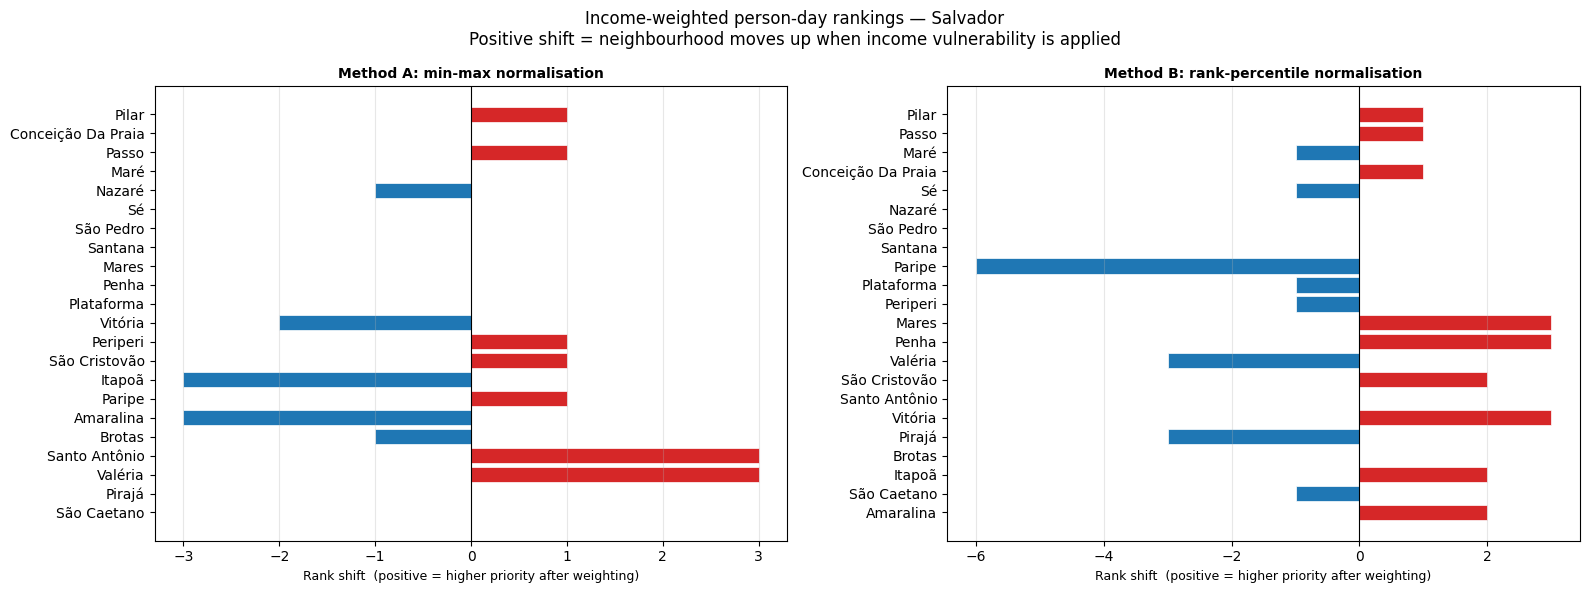

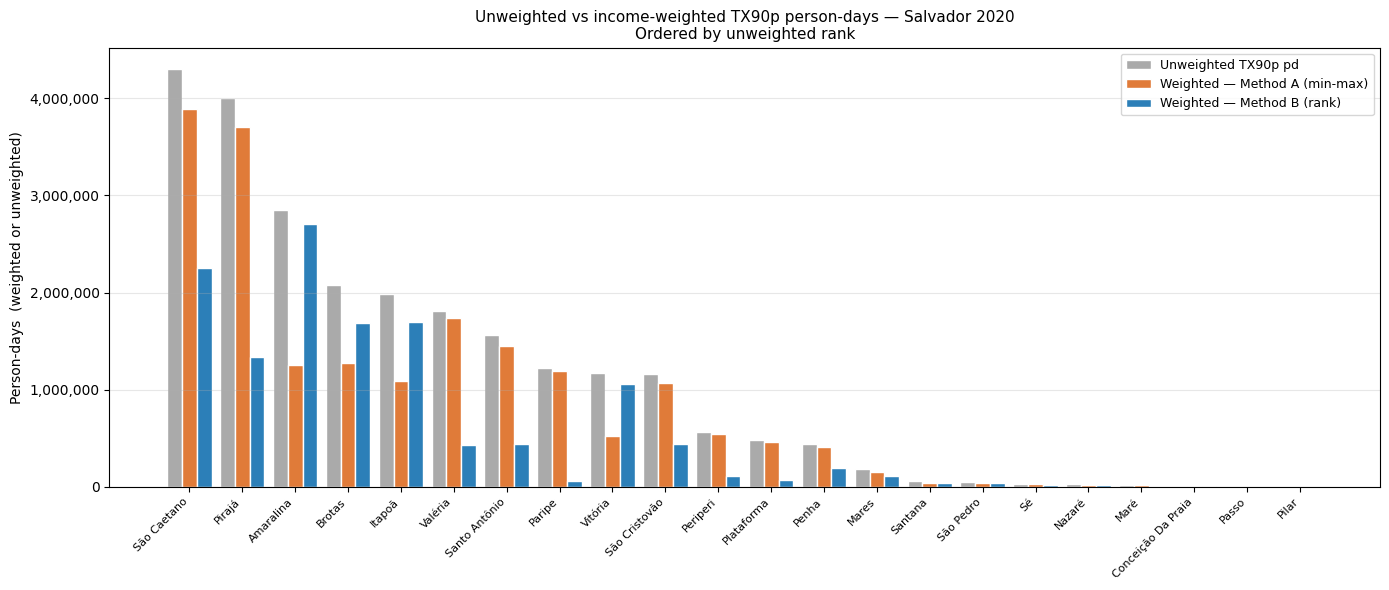

In [25]:
df['rank_shift_minmax'] = df['rank_unweighted'] - df['rank_weighted_minmax']  # positive = moved up
df['rank_shift_rank']   = df['rank_unweighted'] - df['rank_weighted_rank']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Income-weighted person-day rankings — Salvador\n'
    'Positive shift = neighbourhood moves up when income vulnerability is applied',
    fontsize=12,
)

for ax, method, shift_col, weight_col, title_suffix in [
    (axes[0], 'rank_weighted_minmax', 'rank_shift_minmax', 'vulnerability_minmax',
     'Method A: min-max normalisation'),
    (axes[1], 'rank_weighted_rank',   'rank_shift_rank',   'vulnerability_rank',
     'Method B: rank-percentile normalisation'),
]:
    plot_df = df.sort_values(method).reset_index(drop=True)
    colors  = ['#d62728' if s > 0 else '#1f77b4' if s < 0 else '#aaaaaa'
               for s in plot_df[shift_col]]
    bars = ax.barh(plot_df['name'], plot_df[shift_col],
                   color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Rank shift  (positive = higher priority after weighting)', fontsize=9)
    ax.set_title(title_suffix, fontsize=10, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Side-by-side bar: unweighted vs both weighted methods ------------------
fig2, ax2 = plt.subplots(figsize=(14, 6))
plot_df = df.sort_values('rank_unweighted')
x   = np.arange(len(plot_df))
w   = 0.28

ax2.bar(x - w,   plot_df['tx90p_pd'],          width=w, label='Unweighted TX90p pd',
        color='#aaaaaa', edgecolor='white')
ax2.bar(x,       plot_df['weighted_pd_minmax'], width=w, label='Weighted — Method A (min-max)',
        color='#e07b39', edgecolor='white')
ax2.bar(x + w,   plot_df['weighted_pd_rank'],   width=w, label='Weighted — Method B (rank)',
        color='#2c7fb8', edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels(plot_df['name'], rotation=45, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax2.set_ylabel('Person-days  (weighted or unweighted)', fontsize=10)
ax2.set_title(
    f'Unweighted vs income-weighted TX90p person-days — Salvador {DIAG_YEAR}\n'
    'Ordered by unweighted rank',
    fontsize=11,
)
ax2.legend(fontsize=9)
ax2.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8c — Additive composite index (sensitivity check)

The multiplicative index (person-days × vulnerability) erases the contribution of any
neighbourhood where vulnerability = 0 (richest under Method A).  The additive version
`(normalised person-days + vulnerability) / 2` avoids this but blends two incommensurable
quantities.  Shown here as a sensitivity check — if rankings diverge substantially from
the multiplicative index, the choice of combination rule matters and should be flagged.

In [26]:
rho_mult_add_A, _ = spearmanr(df['rank_weighted_minmax'],  df['rank_composite_minmax'])
rho_mult_add_B, _ = spearmanr(df['rank_weighted_rank'],    df['rank_composite_rank'])

print("Spearman \u03c1 between multiplicative and additive rankings:")
print(f"  Method A (min-max): \u03c1 = {rho_mult_add_A:+.3f}")
print(f"  Method B (rank):    \u03c1 = {rho_mult_add_B:+.3f}")
print()
print("If \u03c1 is close to 1.0, the choice of additive vs multiplicative does not matter.")
print("If \u03c1 < 0.9, the combination rule is a meaningful modelling decision.")

# Five-column rank comparison table
rank_compare = df[['name', 'mean_income', 'tx90p_pd',
                    'rank_unweighted',
                    'rank_weighted_minmax', 'rank_weighted_rank',
                    'rank_composite_minmax', 'rank_composite_rank']].copy()
rank_compare.columns = [
    'Neighbourhood', 'Income (BRL)', 'TX90p pd',
    'Rank: unweighted',
    'Rank: mult A', 'Rank: mult B',
    'Rank: add A',  'Rank: add B',
]
rank_compare = rank_compare.sort_values('Rank: mult B')
rank_cols = [c for c in rank_compare.columns if c.startswith('Rank')]
display(
    rank_compare.style
    .format({
        'Income (BRL)': '{:.0f}',
        'TX90p pd':     '{:,.0f}',
        **{c: '{:.0f}' for c in rank_cols},
    })
    .background_gradient(subset=rank_cols, cmap='RdYlGn_r',
                         vmin=1, vmax=len(df))
    .set_caption('Rank comparison: unweighted vs multiplicative vs additive, both normalisation methods')
    .set_table_styles(table_styles)
)

Spearman ρ between multiplicative and additive rankings:
  Method A (min-max): ρ = +0.841
  Method B (rank):    ρ = +0.685

If ρ is close to 1.0, the choice of additive vs multiplicative does not matter.
If ρ < 0.9, the combination rule is a meaningful modelling decision.


,Neighbourhood,Income (BRL),TX90p pd,Rank: unweighted,Rank: mult A,Rank: mult B,Rank: add A,Rank: add B
0,Amaralina,6270,"2,845,064",3,6,1,7,1
6,São Caetano,2059,"4,303,580",1,1,2,1,2
3,Itapoã,5277,"1,982,070",5,8,3,12,3
1,Brotas,4701,"2,078,214",4,5,4,8,4
4,Pirajá,1865,"4,006,178",2,2,5,2,5
21,Vitória,6220,"1,167,467",9,11,6,21,6
5,Santo Antônio,1847,"1,562,627",7,4,7,4,14
7,São Cristovão,1895,"1,161,960",10,9,8,6,13
20,Valéria,1584,"1,814,978",6,3,9,3,12
13,Penha,1937,"445,397",13,13,10,11,16


## Summary

### What this notebook establishes

1. **CV comparison** — income CV is compared against population CV and heat-day CV to
   understand the relative spatial inequality in each dimension across the 22 Salvador
   neighbourhoods.

2. **Income–heat correlation** — if income and heat days are negatively correlated
   (poorer neighbourhoods are hotter), income weighting amplifies the existing heat signal.
   If they are uncorrelated, income weighting reshuffles rankings substantially.

3. **Income-weighted person-days** — two normalisation approaches are shown:
   - **Method A (min-max):** sensitive to the high-income outlier (max ≈ 61 671 BRL)
     which compresses all other values; the richest neighbourhood gets weight = 0.
   - **Method B (rank-percentile):** outlier-resistant, guarantees a smooth
     vulnerability gradient regardless of the income distribution shape.

4. **Combination rule sensitivity** — the additive alternative is provided to check
   whether the multiplicative rule is a decisive modelling choice.

### Known limitations

- Income aggregation is by centroid-within-polygon (simple mean); see the critique section
  for MAUP, equal-weight, and temporal mismatch caveats.
- Income is 2022 census; heat and population are from 2020.
- Equal weighting between income vulnerability and heat/population burden is an
  assumption, not an empirically derived parameter.